# AI Exam Fraud Detection — Model Training

This notebook demonstrates the construction, training, and evaluation of the CNN model
used for detecting exam fraud.

## Environment Setup
Always run this notebook from **inside the virtual environment**:
```powershell
cd ai_service
python -m venv venv
.\venv\Scripts\pip.exe install -r requirements.txt
# Then open Jupyter from within the venv:
.\venv\Scripts\jupyter.exe notebook
```

## 1. Setup and Imports

In [1]:
import sys
# Install all required packages into the active kernel environment
!{sys.executable} -m pip install tensorflow numpy opencv-python-headless scikit-learn \
    mediapipe ultralytics librosa soundfile tensorflow-hub matplotlib jupyter -q

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os
import numpy as np

## 2. Define CNN Architecture
We use a lightweight Convolutional Neural Network (CNN) designed for real-time inference on standard hardware.

In [3]:
def build_model(input_shape=(128, 128, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━┳━━━━━┳━━━┓
┃ Layer  ┃ Ou… ┃ … ┃
┃ (type) ┃ Sh… ┃ # ┃
┡━━━━━━━━╇━━━━━╇━━━┩
│ conv2d │ (N… │ … │
│ (Conv… │ 12… │   │
│        │ 12… │   │
│        │ 32) │   │
├────────┼─────┼───┤
│ max_p… │ (N… │ 0 │
│ (MaxP… │ 63, │   │
│        │ 63, │   │
│        │ 32) │   │
├────────┼─────┼───┤
│ conv2… │ (N… │ … │
│ (Conv… │ 61, │   │
│        │ 61, │   │
│        │ 64) │   │
├────────┼─────┼───┤
│ max_p… │ (N… │ 0 │
│ (MaxP… │ 30, │   │
│        │ 30, │   │
│        │ 64) │   │
├────────┼─────┼───┤
│ conv2… │ (N… │ … │
│ (Conv… │ 28, │   │
│        │ 28, │   │
│        │ 12… │   │
├────────┼─────┼───┤
│ max_p… │ (N… │ 0 │
│ (MaxP… │ 14, │   │
│        │ 14, │   │
│        │ 12… │   │
├────────┼─────┼───┤
│ flatt… │ (N… │ 0 │
│ (Flat… │ 25… │   │
├────────┼─────┼───┤
│ dense  │ (N… │ … │
│ (Dens… │ 51… │   │
├────────┼─────┼───┤
│ dropo… │ (N… │ 0 │
│ (Drop… │ 51… │   │
├────────┼─────┼───┤
│ dense… │ (N… │ … │
│ (Dens… │ 1)  │   │
└────────┴─────┴───┘

 Total params: 12,939,329 (49.36 MB)

 Trainable params: 12,939,329 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Data Loading & Augmentation
We use `ImageDataGenerator` to rescale images and apply random transformations to improve model robustness.

In [4]:
# PATHS - Update these to your actual dataset location
dataset_path = 'dataset' 
train_dir = os.path.join(dataset_path, 'train')
validation_dir = os.path.join(dataset_path, 'validation')

# Check if dataset exists before running
if os.path.exists(train_dir):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True)

    validation_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(128, 128),
        batch_size=32,
        class_mode='binary')

    validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(128, 128),
        batch_size=32,
        class_mode='binary')
else:
    print("Dataset not found. Please download and extract dataset to ./dataset folder.")

Found 9576 images belonging to 2 classes.


Found 2394 images belonging to 2 classes.


## 4. Train Model
Execute the training process.

In [5]:
if os.path.exists(train_dir):
    history = model.fit(
        train_generator,
        steps_per_epoch=max(1, train_generator.samples // 32),
        epochs=10,
        validation_data=validation_generator,
        validation_steps=max(1, validation_generator.samples // 32)
    )
    
    # Save the model
    model.save('exam_fraud_model.h5')
    print("Model saved.")

Epoch 1/10


  1/299 ━━━━━━━━━━━━━━━━━━━━ 26:39 5s/step - accuracy: 0.6875 - loss: 0.6812

  2/299 ━━━━━━━━━━━━━━━━━━━━ 1:33 316ms/step - accuracy: 0.6328 - loss: 0.6951

  3/299 ━━━━━━━━━━━━━━━━━━━━ 2:06 428ms/step - accuracy: 0.6163 - loss: 0.7803

  4/299 ━━━━━━━━━━━━━━━━━━━━ 2:21 478ms/step - accuracy: 0.5990 - loss: 0.8509

...

299/299 ━━━━━━━━━━━━━━━━━━━━ 186s 621ms/step - accuracy: 1.0000 - loss: 1.7999e-06 - val_accuracy: 1.0000 - val_loss: 1.0340e-07


Epoch 10/10


  1/299 ━━━━━━━━━━━━━━━━━━━━ 49s 165ms/step - accuracy: 1.0000 - loss: 8.3022e-07

299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 1.0000 - loss: 8.3022e-07 - val_accuracy: 1.0000 - val_loss: 1.0326e-07


Model saved.


## 5. Visualizing Performance
Plotting Accuracy and Loss curves.

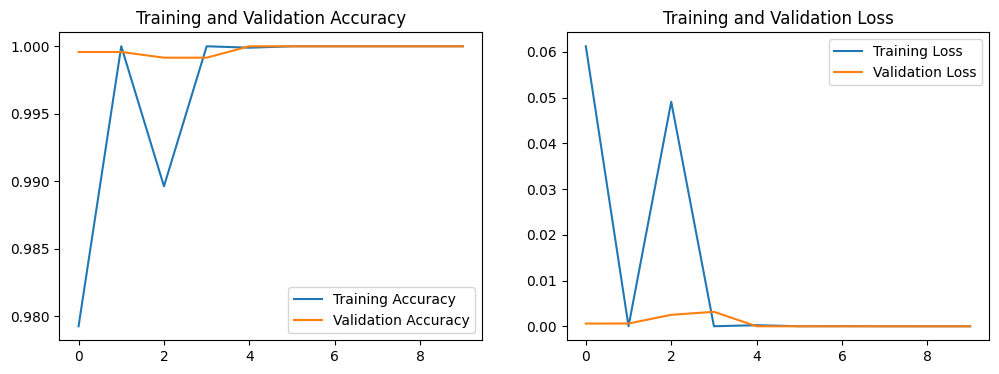

In [6]:
if 'history' in locals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()